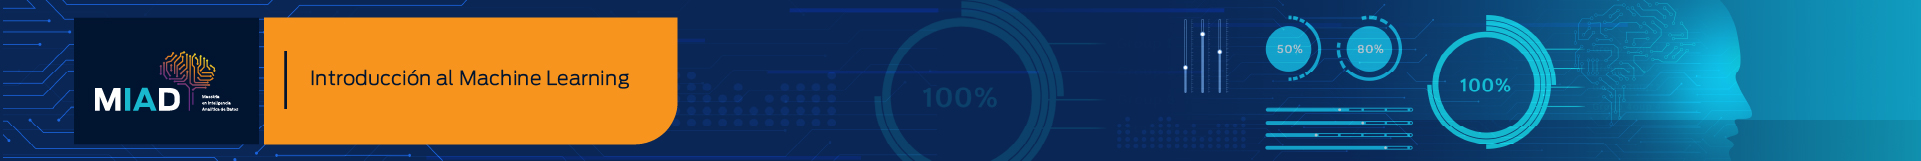

# Introducción al Machine Learning - Semana 2
## Caso: Modelos lineales para regresión, muestreo y selección del mejor modelo

### Propósito de la actividad

En esta actividad podrán poner en práctica, con un conjunto de datos reales, su habilidad para implementar modelos lineales y seleccionar aquel que tenga el mejor desempeño para resolver un problema de regresión. En particular, se deberán implementar modelos lineales de componentes principales, partial least squares y regularización.

Además, como en todo procedimiento de analítica de datos, se evaluará la exploración preliminar de los datos por medio de herramientas como histogramas, correlogramas y estadísticas descriptivas.

### Instrucciones generales

1. Para desarrollar el notebook, lo deberán descargar a un repositorio (pueden escoger el repositorio de su preferencia) para que lo puedan trabajar grupalmente.

2. Los procedimientos en el notebook deberán responderse en los espacios especificados para tal fin, debajo de cada uno de los puntos.

3. Para que la actividad sea calificada, deberán subir únicamente este mismo archivo con la extensión ".ipynb" a la actividad de "entrega calificada por el personal" correspondiente a este caso.

4. El archivo que suban debe poder ejecutarse localmente cuando sea descargado por el tutor, asumiendo que la base de datos de la actividad ya ha sido importada en el correspondiente archivo separado por comas (.csv).

### Criterios de evaluación

Los criterios que se evaluarán son:   

Análisis preliminar de variables: Se presentan correlogramas, histogramas y estadísticas descriptivas de las variables de la base de datos y se hace un análisis coherente de cada uno de ellos. [10 puntos] 

Estimación del modelo usando componentes principales: Se estima el modelo usando componentes principales, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación del modelo usando PCA y el método forward: Se estima el modelo usando el método forward con componentes principales, se responde si es el mismo modelo del punto 2, se evalúa su desempeño en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [30 puntos] 

Estimación del modelo de partial least squares: Se estima el modelo usando partial least squares, se evalúa en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [20 puntos] 

Estimación de un modelo de penalización: Se estima algún modelo de penalización, se evalúa en la muestra de test y se analizan correctamente los resultados y el procedimiento realizado. [15 puntos] 

Elección del mejor modelo: Se elige el mejor modelo de acuerdo a los resultados obtenidos y se justifica adecuadamente la elección. [5 puntos] 


### Datos

Existe gran variedad de bases de datos reales disponibles en internet usadas por la comunidad académica para la evaluación de modelos predictivos.

En esta ocasión usarán una base de datos disponible en la página R-Data. Esta base de datos corresponde a "Hitters", la cual contiene 20 variables de jugadores de la Major League Baseball en las temporadas de 1986 y 1987. De esta manera, el objetivo de la actividad es predecir el salario de un jugador basado en las características que describen las variables predictivas.

Por lo anterior, en primer lugar deberán descargar la base de datos del siguiente enlace: https://drive.google.com/drive/folders/1YuWR657GDARSMPkUCVFNd2a5mX5zL16A?usp=sharing

Finalmente, para resolver los puntos de esta actividad deberán tener en cuenta únicamente las variables continuas (se deben eliminar las variables categóricas) y deberán eliminar las observaciones con datos faltantes.


Cargar datos

In [16]:
#  Cargar librerías
import numpy as np
from sklearn import datasets
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from sklearn.cross_decomposition import PLSRegression
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns
from sklearn.linear_model import RidgeCV
from sklearn.linear_model import Ridge
from sklearn.linear_model import LassoCV
from sklearn.linear_model import Lasso
from sklearn.linear_model import ElasticNetCV
from sklearn.linear_model import ElasticNet
from sklearn.model_selection import cross_val_score
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold




In [2]:
#Cargar datos
df = pd.read_csv("Hitters.csv", sep=",")

In [3]:
# Se eliminar filas con valores faltantes en la columna 'Salary' ya que es la columna que se debe predecir y la variable de nombre ya que esta no afecta el modelo por se unica para identificar cada fila
df.dropna(subset=['Salary'], inplace=True)
df.reset_index(drop=True, inplace=True)
ytotal = df['Salary']
Xtotal = df.drop(columns=['Salary', 'Unnamed: 0'])

In [4]:
# Seleccionar columnas categóricas, enteras y de punto flotante
catcols = Xtotal.select_dtypes(exclude=['int64', 'float64']).columns
intcols = Xtotal.select_dtypes(include=['int64']).columns
floatcols = Xtotal.select_dtypes(include=['float64']).columns

# Codificación de variables categóricas en xtotal para evitar que new league, division, league eviten que se pueda estandarizar en los modelos.
Xtotal = pd.get_dummies(Xtotal, columns=catcols, dtype=int, drop_first=True)
Xtotal

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,League_N,Division_W,NewLeague_N
0,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,1,1,1
1,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,0,1,0
2,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,1,0,1
3,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,1,0,1
4,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
258,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3,1,0,1
259,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20,0,0,0
260,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7,0,1,0
261,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12,0,0,0


In [5]:
#División de train y test con 33% en test
XTrain, XTest, yTrain, yTest = train_test_split(Xtotal, ytotal, test_size=0.33, random_state=0)

### 1. Análisis preliminar de variables (10 puntos)
Realicen un análisis preliminar de los predictores y de la variable de respuesta (correlogramas, histogramas y estadísticas descriptivas).

            AtBat        Hits       HmRun        Runs        RBI       Walks  \
count  176.000000  176.000000  176.000000  176.000000  176.00000  176.000000   
mean   406.602273  108.579545   11.375000   54.909091   50.81250   41.028409   
std    146.146231   45.509741    8.573464   25.156487   24.42631   20.751710   
min     20.000000    1.000000    0.000000    0.000000    0.00000    0.000000   
25%    283.000000   73.750000    5.000000   35.000000   31.00000   26.000000   
50%    410.500000  105.000000    9.000000   51.000000   47.00000   37.000000   
75%    523.750000  141.000000   16.000000   71.250000   70.25000   53.250000   
max    687.000000  238.000000   40.000000  130.000000  113.00000  105.000000   

            Years       CAtBat        CHits      CHmRun        CRuns  \
count  176.000000   176.000000   176.000000  176.000000   176.000000   
mean     7.210227  2597.630682   702.556818   63.750000   345.670455   
std      4.613782  2100.943199   584.741620   71.244729   293.3

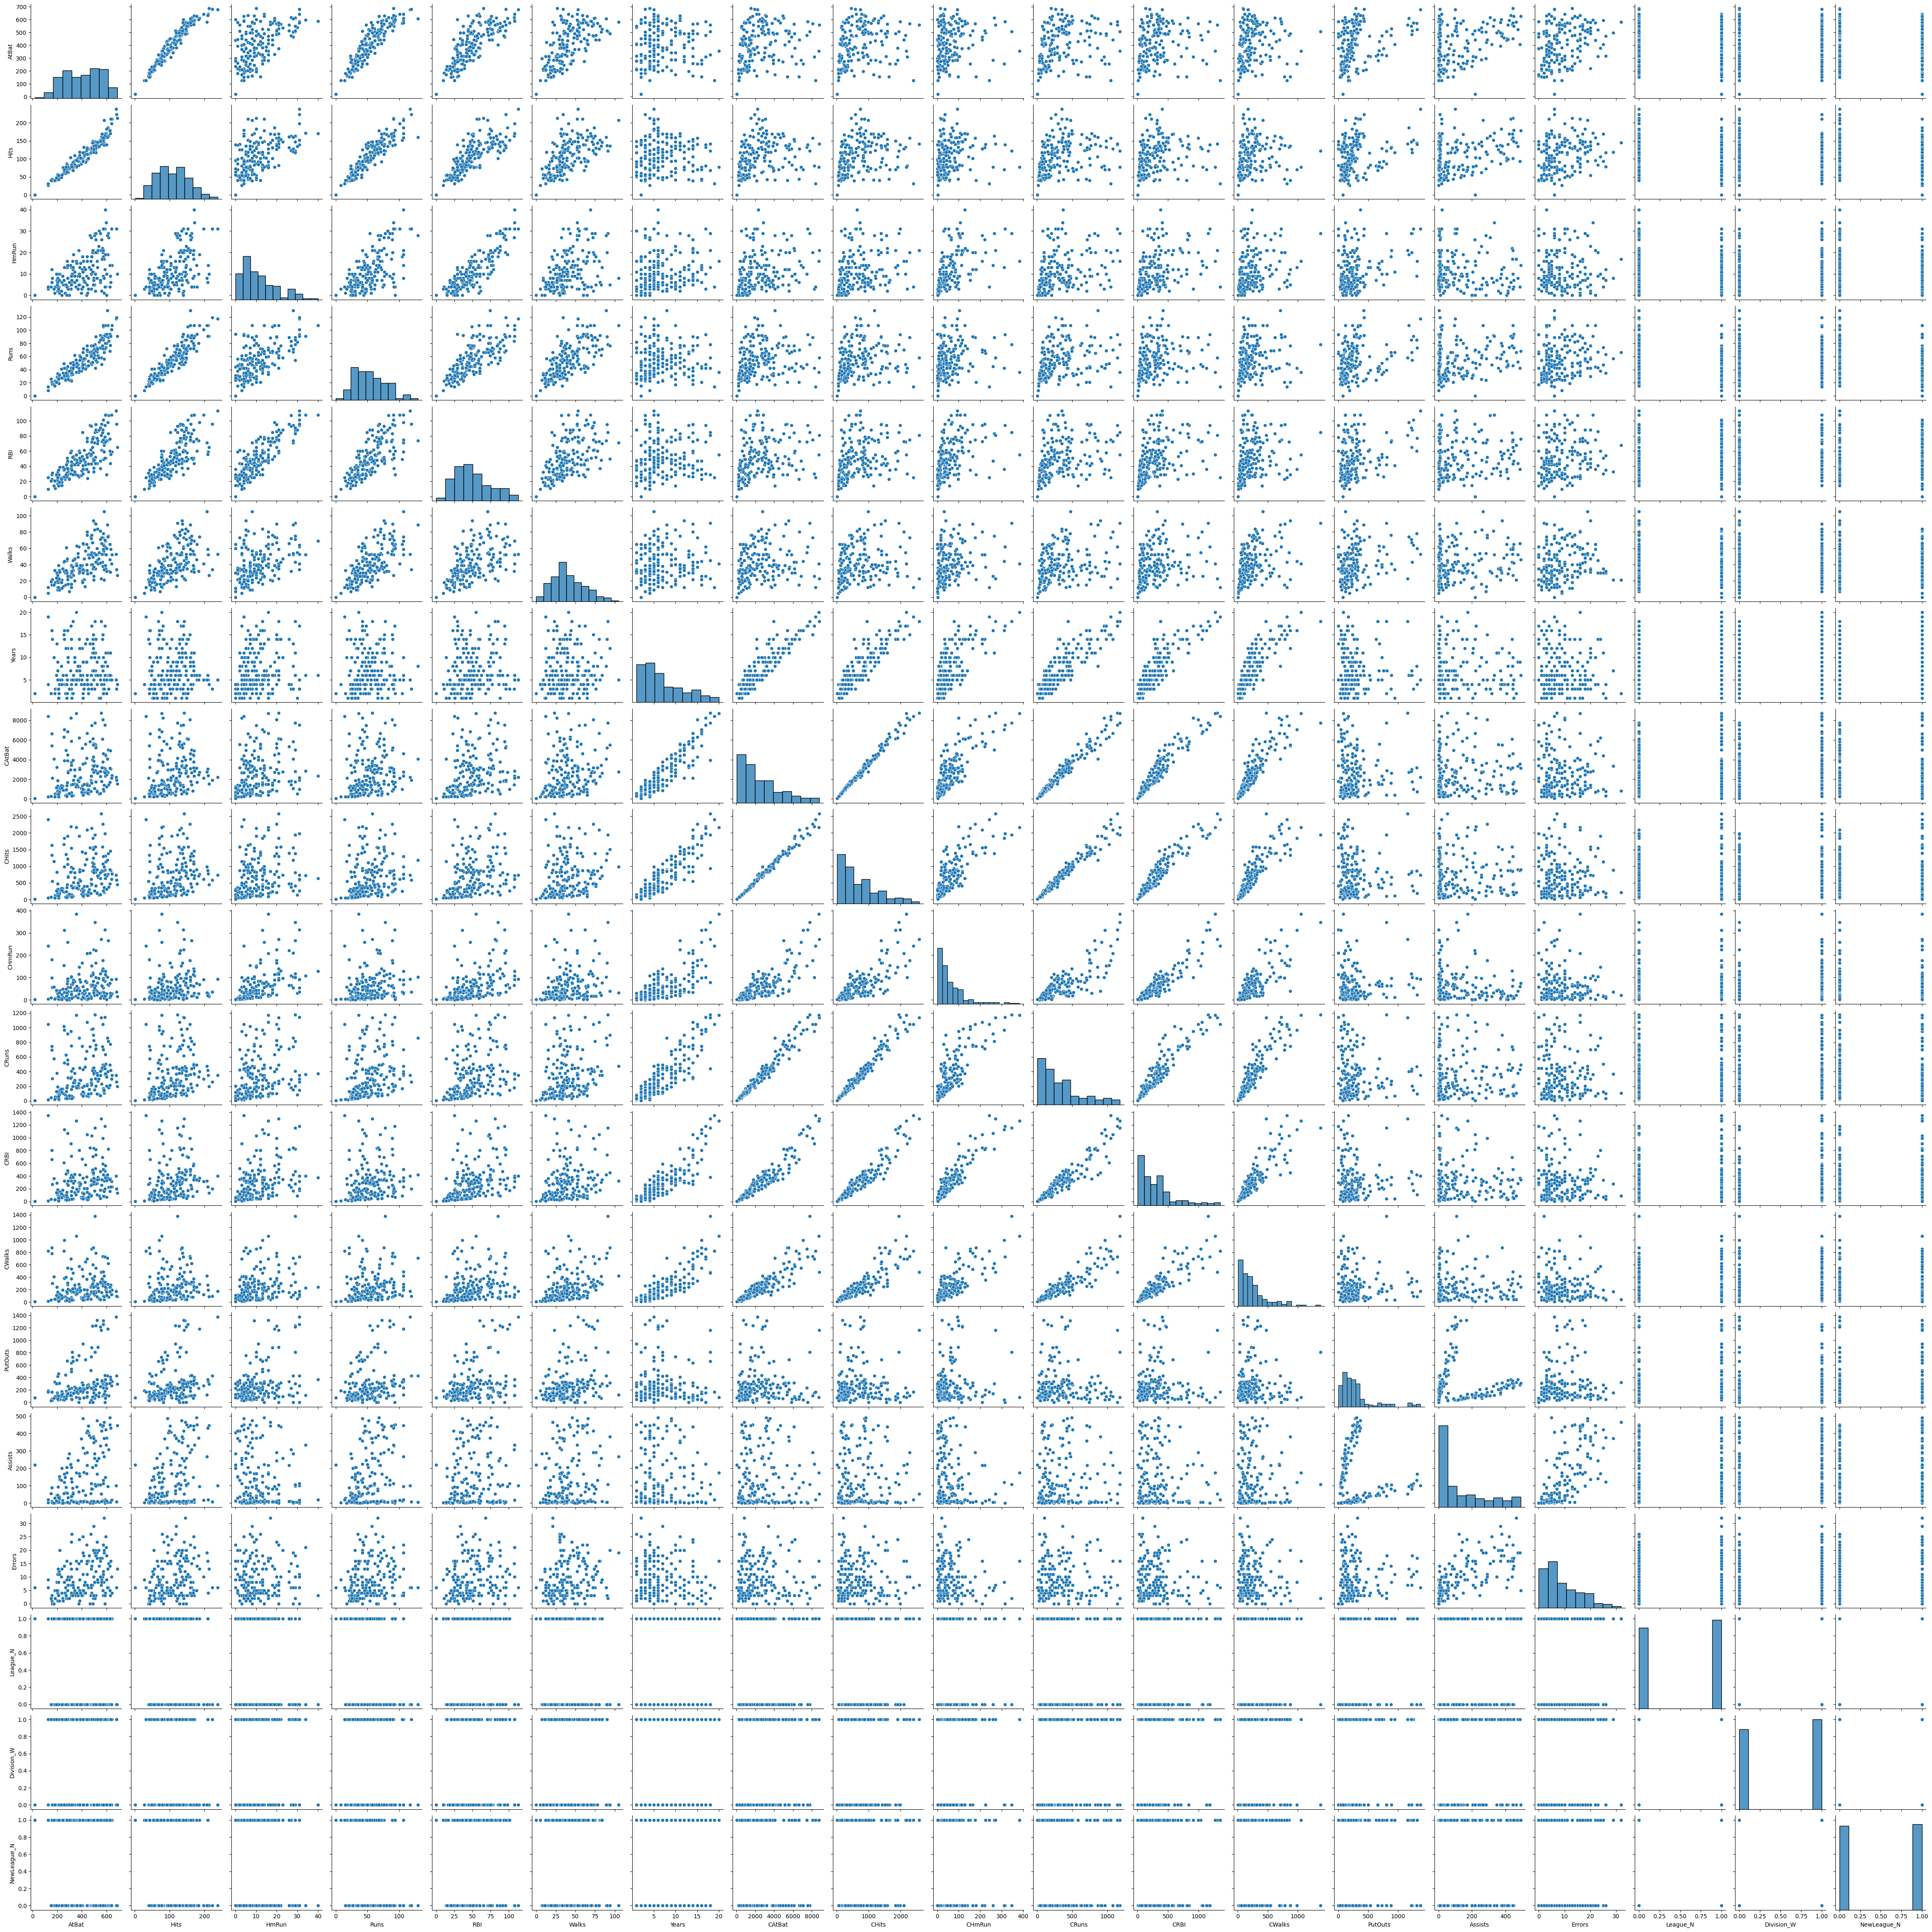

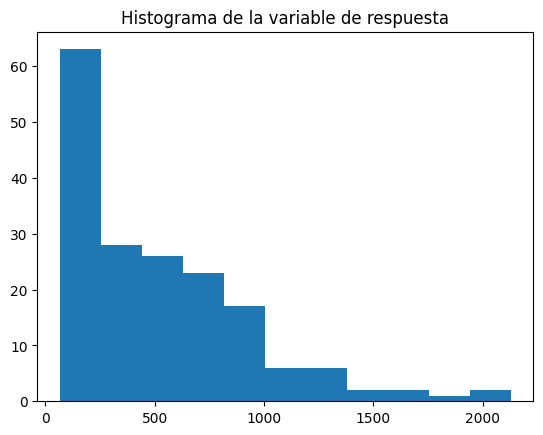

In [19]:
XTrainAuxiliar=pd.DataFrame(XTrain)
print(XTrainAuxiliar.describe())

yTrainAuxiliar=pd.DataFrame(yTrain)
print(yTrainAuxiliar.describe())


XTrainAuxiliar=pd.DataFrame(XTrain)
sns.pairplot(XTrainAuxiliar, kind="scatter")
plt.show()

plt.hist(yTrain, bins='auto')
mensaje = ['Histograma de la variable de respuesta']
plt.title(" ".join(mensaje))
plt.show()

(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 1)

## DESCRICPIÓN Y ANALSIS 1

### 2. Estimación del modelo usando componentes principales (20 puntos)
Estimen un modelo predictivo usando la muestra de entrenamiento usando componentes principales y evalúen su desempeño en la muestra de test.

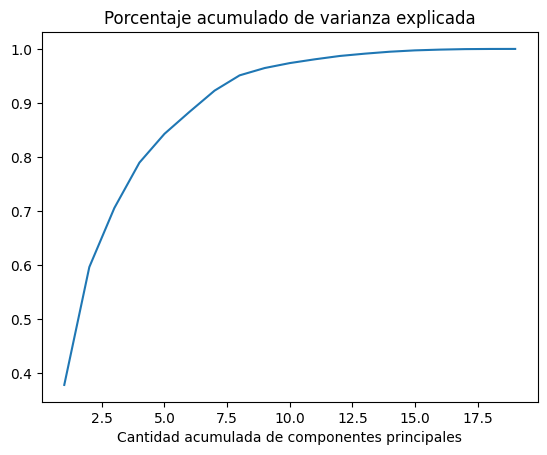

In [6]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 2 ####

scaler = StandardScaler()
scaler.fit(XTrain)
XEscaladoTrain=scaler.transform(XTrain)

p=len(XEscaladoTrain[1,])
pca = PCA(n_components=p).fit(XEscaladoTrain)
A=pca.components_

varianzaExplicada=pca.explained_variance_
porcentajeVarianzaExplicada=pca.explained_variance_ratio_
plt.plot(range(1,p+1),np.cumsum(porcentajeVarianzaExplicada))
plt.xlabel('Cantidad acumulada de componentes principales')
plt.title('Porcentaje acumulado de varianza explicada')
plt.show()

In [7]:
nComponentesElegidas=7

ZTotalTrain=np.matmul(XEscaladoTrain,A)
ZTrain = ZTotalTrain[:,range(nComponentesElegidas)]

regPCA = LinearRegression()
regPCA.fit(ZTrain, yTrain)
XEscaladoTest=scaler.transform(XTest)
ZTotalTest=np.matmul(XEscaladoTest,A)
ZTest = ZTotalTest[:,range(nComponentesElegidas)]
prediccionPCA=regPCA.predict(ZTest)
MSEPCA=np.average(np.square(prediccionPCA-yTest))
print('MSE regresión por componentes principales:')
print(MSEPCA)

MSE regresión por componentes principales:
148739.41772864902


## Descripción y análisis 2

Inicialmente, para construir la matriz XTotal, se eliminó la variable correspondiente al nombre del jugador, ya que esta es un identificador único y no aporta información predictiva relevante al modelo. Posteriormente, las variables categóricas League, NewLeague y Division fueron transformadas mediante codificación *dummy*, con el fin de poder incorporarlas al análisis.

Luego, el conjunto de datos fue dividido en muestras de entrenamiento y prueba, asignando un 33% de los datos al conjunto de prueba con el objetivo de evaluar el desempeño predictivo del modelo en datos no utilizados durante el entrenamiento.

Posteriormente, se realizó el escalamiento de las variables de entrenamiento paso fundamental antes de aplicar PCA, debido a que este método es sensible a la escala de las variables.

A continuación, se graficó el porcentaje acumulado de varianza explicada con el fin de analizar cuánta información es capturada a medida que aumenta el número de componentes principales. A partir de esta gráfica se observa que aproximadamente 7 componentes principales explican cerca del 90% de la varianza total, partiendo de un conjunto original de 20 variables Con base en este resultado, se seleccionaron estos 7 componentes, ya que permiten conservar la mayor parte de la información relevante, reducir la dimensionalidad del problema, disminuir el riesgo de sobreajuste (overfitting).

En cuanto al desempeño predictivo, el modelo de regresión por componentes principales obtuvo un MSE en el conjunto de prueba de 128,013.68. Aunque este valor puede parecer elevado en términos absolutos, su interpretación debe realizarse de manera relativa, comparándolo con otros modelos de referencia. Por lo tanto, en esta etapa el resultado sirve como punto base para posteriores comparaciones.


### 3. Estimación del modelo usando PCA y el método forward (30 puntos)
Ahora construyan su propio algoritmo para hacer una regresión por componentes principales, en donde primero calculen los componentes y después realicen un proceso de selección de variables secuencial (forward) que permita encontrar el mejor modelo. Todo lo anterior en la muestra de entrenamiento.

Finalmente, evalúen el desempeño en test.

Una vez hecho este procedimiento respondan a la siguiente pregunta:

¿Es el mismo modelo del punto anterior (punto 2)? 

In [ ]:
n_features = XTrain.shape[1]
kf = KFold(n_splits=5, shuffle=True, random_state=42)

seleccionados = []
disponibles = list(range(n_features))
mejor_mse = np.inf
historial_mse = []

In [15]:
while disponibles:
    mejor_comp = None
    mejor_mse_temp = np.inf
    
    for comp in disponibles:
        prueba = seleccionados + [comp]
        mses_folds = []
        
        # Cross-validation 
        for train_idx, val_idx in kf.split(XTrain):
            X_tr, X_val = XTrain.iloc[train_idx], XTrain.iloc[val_idx]
            y_tr, y_val = yTrain.iloc[train_idx], yTrain.iloc[val_idx]
            
            # Scaler dentro del fold
            scaler = StandardScaler()
            X_tr_s = scaler.fit_transform(X_tr)
            X_val_s = scaler.transform(X_val)
            
            # PCA full dentro del fold
            pca = PCA(n_components=n_features)
            Z_tr = pca.fit_transform(X_tr_s)
            Z_val = pca.transform(X_val_s)
            
            # Seleccionar PCs específicos
            Z_tr_sub = Z_tr[:, prueba]
            Z_val_sub = Z_val[:, prueba]
            
            # Regresión
            lr = LinearRegression()
            lr.fit(Z_tr_sub, y_tr)
            y_pred = lr.predict(Z_val_sub)
            mses_folds.append(mean_squared_error(y_val, y_pred))
        
        mse_cv = np.mean(mses_folds)
        if mse_cv < mejor_mse_temp:
            mejor_mse_temp = mse_cv
            mejor_comp = comp
    
    # Criterio de parada
    if mejor_mse_temp < mejor_mse - 1e-6:
        seleccionados.append(mejor_comp)
        disponibles.remove(mejor_comp)
        mejor_mse = mejor_mse_temp
        historial_mse.append(mejor_mse)
        print(f"Paso {len(seleccionados)}: Agregado PC{mejor_comp + 1}, MSE_CV = {mejor_mse:.4f}")
    else:
        print("\nNo hay mejora al agregar más componentes. Deteniendo.")
        break

print("RESULTADO:")
print("Componentes seleccionados:", [f"PC{c+1}" for c in seleccionados])
print("Número de componentes:", len(seleccionados))




No hay mejora al agregar más componentes. Deteniendo.
RESULTADO:
Componentes seleccionados: ['PC1', 'PC4', 'PC14', 'PC16', 'PC17', 'PC2', 'PC18', 'PC13', 'PC15', 'PC19']
Número de componentes: 10


In [ ]:
# ------ Modelo final en TODO el train ----
scaler_final = StandardScaler()
X_train_s = scaler_final.fit_transform(XTrain)
X_test_s = scaler_final.transform(XTest)

pca_final = PCA(n_components=n_features)
Z_train = pca_final.fit_transform(X_train_s)
Z_test = pca_final.transform(X_test_s)

Z_train_sub = Z_train[:, seleccionados]
Z_test_sub = Z_test[:, seleccionados]

lr_final = LinearRegression()
lr_final.fit(Z_train_sub, yTrain)

y_pred_train = lr_final.predict(Z_train_sub)
y_pred_test = lr_final.predict(Z_test_sub)

mse_train = mean_squared_error(yTrain, y_pred_train)
mse_test = mean_squared_error(yTest, y_pred_test)
r2_train = r2_score(yTrain, y_pred_train)
r2_test = r2_score(yTest, y_pred_test)

print("\n=== EVALUACIÓN FINAL ===")
print(f"MSE Train: {mse_train:.4f}")
print(f"MSE Test:  {mse_test:.4f}")
print(f"R² Train:  {r2_train:.4f}")
print(f"R² Test:   {r2_test:.4f}")



=== EVALUACIÓN FINAL ===
MSE Train: 85549.8855
MSE Test:  147212.6160
R² Train:  0.4933
R² Test:   0.4543


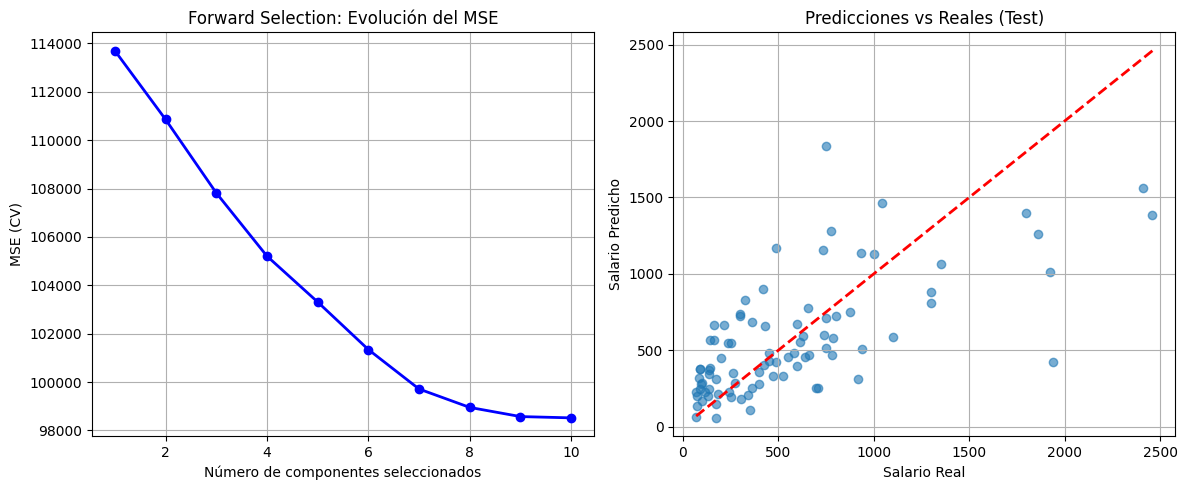

In [14]:
# ===== Gráficos =====
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(range(1, len(historial_mse) + 1), historial_mse, 'bo-', linewidth=2)
plt.xlabel('Número de componentes seleccionados')
plt.ylabel('MSE (CV)')
plt.title('Forward Selection: Evolución del MSE')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(yTest, y_pred_test, alpha=0.6)
plt.plot([yTest.min(), yTest.max()], [yTest.min(), yTest.max()], 'r--', lw=2)
plt.xlabel('Salario Real')
plt.ylabel('Salario Predicho')
plt.title('Predicciones vs Reales (Test)')
plt.grid(True)

plt.tight_layout()
plt.show()

(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 3)

## DESCRICPIÓN Y ANALSIS 3

### 4. Estimación del modelo de partial least squares (20 puntos)
Predigan usando partial least squares y evalúen en la muestra de test. Concluyan sobre el poder predictivo del modelo estimado.

In [19]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 4 ####


pls = PLSRegression(n_components=XTrain.shape[1])
pls.fit(XTrain, yTrain)
prediccionPLS=pls.predict(XTest)
prediccionPLS=np.hstack(prediccionPLS)
MSEPLS=np.average(np.square(prediccionPLS-yTest))
print('MSE regresión por partial least squares:')
print(MSEPLS)

MSE regresión por partial least squares:
140499.91145894604


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 4)

## DESCRIPCIÓN Y ANALISIS 4

Para este punto se implementó un modelo de Partial Least Squares Regression (PLS) utilizando xtrain que se basa en en las variables predictorias menos los nombres y las categoricas como dummies. A diferencia del método PCR, PLS construye componentes maximizando simultáneamente la varianza explicada en las variables predictoras y su relación con la variable respuesta,

El modelo fue entrenado utilizando el conjunto de entrenamiento y posteriormente se generaron predicciones sobre el conjunto de prueba. En este caso no se realiza el escalonamiento de los datos ya que a diferencia de PCA no se debe escalar porque se hace dentro de la función, debido a esto se uso el largo de xtrain como la cantidad de componentes.

El valor obtenido de MSE en el conjunto de prueba fue 140,499.91

Este resultado permite establecer una base de comparación con otros enfoques como el previamente usado PCA. En particular, al comparar los valores de MSE entre modelos, encontramos que en PCA tiene un desempeño mejor que PLS para este conjunto de datos, con una diferencia de 12486.22 en el MSE. De esta forma, se escoge apriri el modelo mencionado.



### 5. Estimación de un modelo de penalización (15 puntos)
Predigan usando un modelo de penalización y evalúen en la muestra de test. Concluyan sobre el poder predictivo del modelo estimado.

c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 152505.3776006177, tolerance: 2411.0752232271284
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3443.254181008786, tolerance: 2411.0752232271284
  model = cd_fast.enet_coordinate_descent_gram(
c:\Users\user\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:614: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations. Duality gap: 3169.8617068175226, tolerance: 2411.0752232271284
  model = cd_fast.enet_coordinate_descent_gram(
c:\

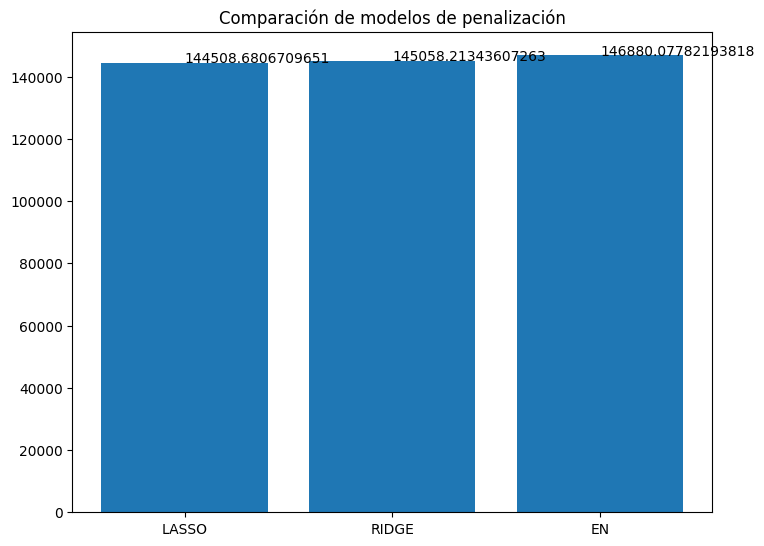

El minimo MSE se obtiene con el modelo de penalización: LASSO con un MSE de: 144508.6806709651


In [20]:
#### Utilicen este espacio para escribir los códigos del procedimiento del punto 5 ####

n_alphas = 200
alphasCalibrar = np.logspace(-10, 2, n_alphas)

modeloLASSO = LassoCV(alphas=alphasCalibrar).fit(XTrain, yTrain)
R2LASSO=modeloLASSO.score(XTrain, yTrain)
coeficientesLASSO=modeloLASSO.coef_
prediccionLASSO=modeloLASSO.predict(XTest)
MSELASSO=np.average(np.square(prediccionLASSO-yTest))



modeloRIDGE = RidgeCV(alphas=alphasCalibrar,store_cv_values=True).fit(XTrain, yTrain)
parametroRIDGE=modeloRIDGE.alpha_
R2RIDGE=modeloRIDGE.score(XTrain, yTrain)
coeficientesRIDGE=modeloRIDGE.coef_
prediccionRIDGE=modeloRIDGE.predict(XTest)
MSERIDGE=np.average(np.square(prediccionRIDGE-yTest))
    


modeloEN = ElasticNetCV(alphas=alphasCalibrar,cv=5, random_state=0).fit(XTrain,yTrain)
parametroEN=modeloEN.alpha_
R2EN=modeloEN.score(XTrain, yTrain)
coeficientesEN=modeloEN.coef_
prediccionEN=modeloEN.predict(XTest)
MSEEN=np.average(np.square(prediccionEN-yTest))


fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de modelos de penalización")
ejeX = ['LASSO', 'RIDGE', 'EN']
ejeY = [MSELASSO,MSERIDGE,MSEEN]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],y[i])
addlabels(ejeX,ejeY,plt)
plt.show()
print("El minimo MSE se obtiene con el modelo de penalización:", ejeX[np.argmin(ejeY)], "con un MSE de:", min(ejeY))


(Utilicen este espacio para describir su procedimiento y escribir su análisis y conclusiones sobre el punto 5)

## DESCRICPIÓN Y ANALSIS 5


Para los modelos con penalización se decidió implementar los tres enfoques principales: LASSO, Ridge y Elastic Net, con el objetivo de identificar cuál de estos métodos se ajusta mejor a las características del conjunto de datos. De esta forma, se pudo comparar el desempeño predictivo de diferentes esquemas de regularización.

En el proceso de calibración se definieron 200 valores candidatos para el parámetro de penalización, los cuales fueron generados en escala logarítmica. Esto permitió que cada modelo evaluara distintos niveles de regularización mediante validación cruzada y seleccionara automáticamente el valor óptimo del parámetro que minimiza el error de predicción.

Posteriormente, se construyó una gráfica comparativa del MSE en el conjunto de prueba para los tres modelos. A partir de esta gráfica se observa que los errores obtenidos son relativamente cercanos entre sí, lo cual indica que los tres métodos presentan un comportamiento predictivo similar sobre el dataset.

Sin embargo, el modelo LASSO presenta el mejor desempeño, obteniendo un MSE inferior en aproximadamente 549.52 unidades respecto a Ridge y 2,371.39 unidades respecto a Elastic Net. En consecuencia, se seleccionó el modelo LASSO como el mejor modelo regularizado para este conjunto de datos y como referencia para la comparación con los demás enfoques implementados.


### 6. Elección del mejor modelo (5 puntos)
¿Cuál modelo de los estimados en este caso resulta mejor para la predicción de la variable de respuesta? Justifiquen su respuesta.

(Utilicen este espacio para escribir su análisis y conclusiones sobre el punto 6)

## DESCRICPIÓN Y ANALSIS 6

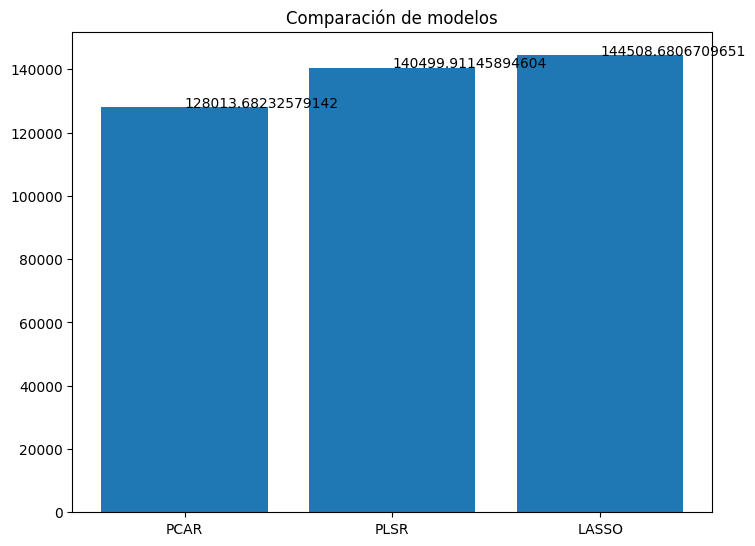

El minimo MSE se obtiene con el modelo: PCAR con un MSE de: 128013.68232579142


In [21]:
fig = plt.figure()
ax = fig.add_axes([0,0,1,1])
ax.set_title("Comparación de modelos")
ejeX = ['PCAR', 'PLSR',"LASSO"]
ejeY = [MSEPCA,MSEPLS,MSELASSO]
ax.bar(ejeX,ejeY)
def addlabels(x,y,plotP):
    for i in range(len(x)):
        plotP.text(i,y[i],y[i])
addlabels(ejeX,ejeY,plt)
plt.show()
print("El minimo MSE se obtiene con el modelo:", ejeX[np.argmin(ejeY)], "con un MSE de:", min(ejeY))